In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [530]:
train = pd.read_csv('train (2).csv')
test = pd.read_csv('test (2).csv')

# **1- Explore Data**

In [531]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [532]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [533]:
n=train.isnull().sum()
n[n>0]

,0
Age,177
Cabin,687
Embarked,2


<Axes: >

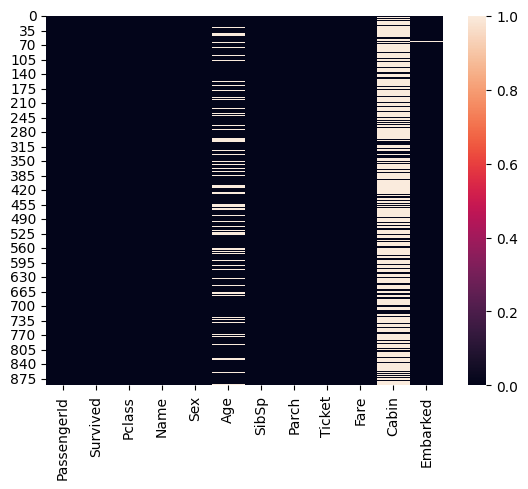

In [534]:
sns.heatmap(train.isnull())

# **2- Clean Data**

In [535]:
def clean(d):
    d.drop(['Fare', 'Cabin', 'Embarked', 'Ticket','Name'], axis=1, inplace=True)
    imputer = SimpleImputer(strategy='mean')
    d[['Age']] = imputer.fit_transform(d[['Age']])
    d.dropna(inplace=True)
    return d

<Axes: >

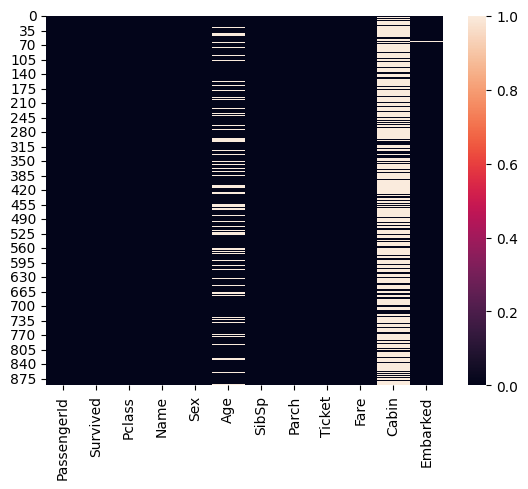

In [536]:
sns.heatmap(train.isnull())

In [537]:
clean(train)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch
0,1,0,3,male,22.000000,1,0
1,2,1,1,female,38.000000,1,0
2,3,1,3,female,26.000000,0,0
3,4,1,1,female,35.000000,1,0
4,5,0,3,male,35.000000,0,0
...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0
887,888,1,1,female,19.000000,0,0
888,889,0,3,female,29.699118,1,2
889,890,1,1,male,26.000000,0,0


In [538]:
clean(test)

,PassengerId,Pclass,Sex,Age,SibSp,Parch
0,892,3,male,34.50000,0,0
1,893,3,female,47.00000,1,0
2,894,2,male,62.00000,0,0
3,895,3,male,27.00000,0,0
4,896,3,female,22.00000,1,1
...,...,...,...,...,...,...
413,1305,3,male,30.27259,0,0
414,1306,1,female,39.00000,0,0
415,1307,3,male,38.50000,0,0
416,1308,3,male,30.27259,0,0


# **Data Analysis**

<Axes: >

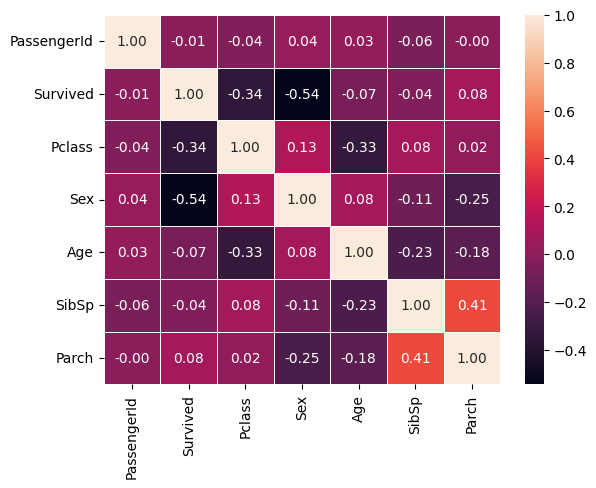

In [539]:
sns.heatmap(corr,annot=True,fmt='.2f',linewidths=.5)

In [540]:
train.Survived.value_counts()

,count
Survived,
0,549
1,342


# **4- Transform Data**

In [541]:
train['Sex'] = train['Sex'].map({'male': 1, 'female': 0})
test['Sex'] = test['Sex'].map({'male': 1, 'female': 0})


In [542]:
train.Sex.value_counts()

,count
Sex,
1,577
0,314


In [543]:
train.Sex

,Sex
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [544]:
train

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch
0,1,0,3,1,22.000000,1,0
1,2,1,1,0,38.000000,1,0
2,3,1,3,0,26.000000,0,0
3,4,1,1,0,35.000000,1,0
4,5,0,3,1,35.000000,0,0
...,...,...,...,...,...,...,...
886,887,0,2,1,27.000000,0,0
887,888,1,1,0,19.000000,0,0
888,889,0,3,0,29.699118,1,2
889,890,1,1,1,26.000000,0,0


In [545]:
test

,PassengerId,Pclass,Sex,Age,SibSp,Parch
0,892,3,1,34.50000,0,0
1,893,3,0,47.00000,1,0
2,894,2,1,62.00000,0,0
3,895,3,1,27.00000,0,0
4,896,3,0,22.00000,1,1
...,...,...,...,...,...,...
413,1305,3,1,30.27259,0,0
414,1306,1,0,39.00000,0,0
415,1307,3,1,38.50000,0,0
416,1308,3,1,30.27259,0,0


# **5- Create Model**

In [546]:
x = train.drop('Survived', axis=1)
y = train['Survived']



In [547]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=.8)

In [548]:

modelx =  GradientBoostingClassifier()
modelx.fit(x, y)



GradientBoostingClassifier()

In [549]:
accuracy = accuracy_score(y_test, modelx.predict(x_test))
print("Accuracy:", accuracy)

Accuracy: 0.888268156424581


In [550]:
lpre = modelx.predict(test)


In [551]:
new_Df = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': lpre
})


In [553]:
new_Df.to_csv('submission}.csv', index=False)
